# SI Model with Vital Dynamics

## Theory

In a pure SI model (no births or deaths) every individual eventually becomes
infectious: I → N as t → ∞.  Adding vital dynamics changes this picture.
With a background per-capita death rate μ and an equal birth rate (so N is
constant), the ODEs become:

$$\frac{dS}{dt} = \mu N - \beta \frac{SI}{N} - \mu S, \qquad
  \frac{dI}{dt} = \beta \frac{SI}{N} - \mu I$$

Setting dI/dt = 0 gives the **endemic equilibrium**:

$$I^* = N\left(1 - \frac{\mu}{\beta}\right)$$

This is meaningful only when β > μ — which is almost always true for real
diseases since transmission rates are far larger than background mortality rates.
Mortality removes infectious individuals before they can infect others, lowering
the eventual prevalence below 100%.

**Goal:** Run `laser.cohorts` with SI components plus vital-dynamics components,
verify that I(t) converges to I* = N(1 − μ/β), and confirm that total
population N(t) remains approximately constant throughout the simulation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from laser.core import PropertySet
from laser.core.utils import grid
from laser.generic.utils import ValuesMap
from laser.cohorts import Model
from laser.cohorts.vitaldynamics import NonDiseaseMortality, ConstantPopBirths
import laser.cohorts.SI as SI

In [2]:
# --- Parameters ---
N        = 100_000
I0       = 10
CDR      = 20          # crude death rate, per 1000 per year
beta_val = 0.3         # transmission rate (per day)
nticks   = 5 * 365    # 5 years
n_nodes  = 1

# CDR per 1000/yr → daily per-capita death rate
r_mortality_val = CDR / 1000 / 365

# --- Scenario ---
scenario = grid(M=1, N=1)
scenario["S"] = N - I0
scenario["I"] = I0

# --- Build model ---
params = PropertySet({"nticks": nticks})
model  = Model(scenario, params)

betas = ValuesMap.from_scalar(beta_val, nticks, n_nodes)

# Component order matters: NonDiseaseMortality before ConstantPopBirths
ndm = NonDiseaseMortality(model, r_mortality=r_mortality_val)
cpb = ConstantPopBirths(model)

model.components = [
    SI.Susceptible(model),
    SI.Infectious(model),
    ndm,
    cpb,
    SI.Transmission(model, beta=betas),
]

model.run()
print("Model run complete.")

Model run complete.


In [3]:
# --- Theoretical endemic equilibrium ---
I_star = N * (1 - r_mortality_val / beta_val)

# --- Observed final value ---
I_final = model.states.I[-1, 0]

print(f"Theoretical I*   : {I_star:,.1f}  ({100 * I_star / N:.2f}% of N)")
print(f"Observed I[-1]   : {I_final:,}  ({100 * I_final / N:.2f}% of N)")
print(f"Relative gap     : {abs(I_final - I_star) / I_star:.3%}")

Theoretical I*   : 99,981.7  (99.98% of N)
Observed I[-1]   : 99,988  (99.99% of N)
Relative gap     : 0.006%


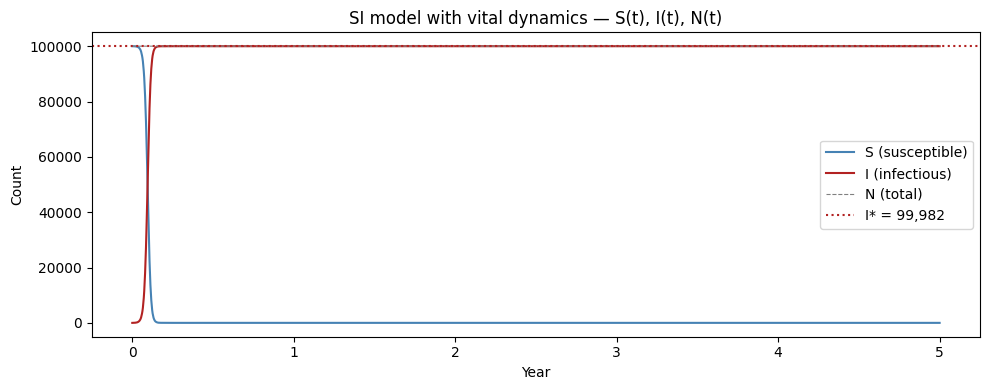

In [4]:
# --- Time series: S(t), I(t), N(t) ---
t = np.arange(nticks + 1)
S_ts = model.states.S[:, 0]
I_ts = model.states.I[:, 0]
N_ts = S_ts + I_ts

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t / 365, S_ts, label="S (susceptible)", color="steelblue")
ax.plot(t / 365, I_ts, label="I (infectious)",  color="firebrick")
ax.plot(t / 365, N_ts, label="N (total)",        color="gray",      linestyle="--", linewidth=0.8)
ax.axhline(I_star, color="firebrick", linestyle=":", linewidth=1.5,
           label=f"I* = {I_star:,.0f}")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
ax.set_title("SI model with vital dynamics — S(t), I(t), N(t)")
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
# --- Sanity check: N(t) should be approximately constant ---
# ConstantPopBirths replaces every death with a birth, so N(t) should
# fluctuate only due to binomial stochasticity in the mortality draws.
N_mean = N_ts.mean()
N_std  = N_ts.std()

print(f"N(t) mean : {N_mean:,.1f}")
print(f"N(t) std  : {N_std:,.2f}")
print(f"Coefficient of variation: {N_std / N_mean:.4%}")

assert N_std / N_mean < 0.01, (
    f"N(t) varies by more than 1% (CV = {N_std / N_mean:.2%}).  "
    "ConstantPopBirths may not be working correctly."
)
print("N(t) approximately constant: OK")

N(t) mean : 100,000.0
N(t) std  : 0.00
Coefficient of variation: 0.0000%
N(t) approximately constant: OK
